[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/snuuq/ztm-tutorial/blob/main/week2/assignment.ipynb)

> **Colab 사용 시**: 열자마자 `파일 → Drive에 사본 저장`으로 사본을 만들어 작업하세요.
> 노트북이 만드는 파일(`training_curves.png`, `decision_boundary_*.png`)은 좌측 파일 패널에서 다운로드할 수 있고, 세션이 초기화되면 사라집니다.

# 2주차 과제 — XOR 데이터의 비선형 결정경계

2장에서 본 분류 워크플로를 noisy XOR 데이터에 적용합니다.
비선형 층이 있는 모델과 없는 모델을 같은 조건에서 학습해 결정경계를 비교합니다.
필요한 구현은 교재 [02장](https://www.learnpytorch.io/02_pytorch_classification/)의 데이터 준비, logits 변환, 학습 루프, 비선형 절에서 확인할 수 있습니다.

## 해야 할 일
1. 2차원 XOR 데이터를 직접 만들고 80:20으로 분할
2. Linear 층만 있는 모델과 ReLU가 포함된 모델 작성
3. logits를 확률과 라벨로 변환
4. 두 모델을 같은 조건에서 학습하고 test accuracy 비교
5. loss/accuracy 곡선과 결정경계 저장
6. Linear 층만 여러 개 연결했을 때 XOR을 풀기 어려운 이유 설명

## 규칙
- `# TODO` 부분을 채우세요. 그 외 제공 코드는 수정하지 않아도 됩니다.
- 재현성을 위해 시드는 제공된 값(2525)을 그대로 쓰세요.
- 학습할 때 `BCEWithLogitsLoss`에는 sigmoid를 거치지 않은 logits를 전달하세요.

## 0. 준비

Library import와 device 설정, 시드 고정.

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(torch.__version__, "| device:", device)

RANDOM_SEED = 2525
torch.manual_seed(RANDOM_SEED)

2.13.0 | device: mps


## 1. Noisy XOR 데이터 생성 & 랜덤 분할

두 좌표의 부호가 서로 다르면 1, 같으면 0인 XOR 데이터를 만듭니다.
라벨을 만든 뒤 입력에 작은 노이즈를 더해 경계 근처의 샘플을 조금 어렵게 만듭니다.

In [2]:
torch.manual_seed(RANDOM_SEED)
n_samples = 1200

# TODO: 각 좌표가 [-2, 2) 범위인 (1200, 2) 텐서를 만드세요
X = (torch.rand(1200, 2) * 4) - 2

# TODO: 두 좌표의 부호가 서로 다르면 1, 같으면 0이 되도록 XOR 라벨을 만드세요
#       y의 dtype은 torch.float32, shape는 (1200,)이어야 합니다.
y = (X[:,0]*X[:,1] > 0).float()

# 입력에만 노이즈를 더합니다. 이 줄은 그대로 두세요.
X = X + 0.15 * torch.randn_like(X)

# TODO: train_test_split으로 80:20 분할하세요.
#       random_state=RANDOM_SEED, stratify=y.numpy()를 사용하세요.
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(X ,y, test_size=0.2, random_state=RANDOM_SEED, stratify=y.numpy())

# TODO: 분할 결과를 torch.float32 텐서로 바꾸세요
X_train, X_test = torch.tensor(X_train_np, dtype=torch.float32), torch.tensor(X_test_np, dtype=torch.float32)
y_train, y_test = torch.tensor(y_train_np, dtype=torch.float32), torch.tensor(y_test_np, dtype=torch.float32)


/var/folders/45/py660m1n7w1grzhxqcysk0dc0000gp/T/ipykernel_2984/2433828924.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train, X_test = torch.tensor(X_train_np, dtype=torch.float32), torch.tensor(X_test_np, dtype=torch.float32)
/var/folders/45/py660m1n7w1grzhxqcysk0dc0000gp/T/ipykernel_2984/2433828924.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train, y_test = torch.tensor(y_train_np, dtype=torch.float32), torch.tensor(y_test_np, dtype=torch.float32)


In [3]:
# 확인: torch.Size([960, 2]) torch.Size([240, 2])
print(X_train.shape, X_test.shape)
# 확인: torch.float32 torch.float32
print(X_train.dtype, y_train.dtype)

torch.Size([960, 2]) torch.Size([240, 2])
torch.float32 torch.float32


## 2. 데이터 시각화

XOR 데이터는 직선 하나로 두 클래스를 나눌 수 있는지 그림으로 먼저 확인합니다.

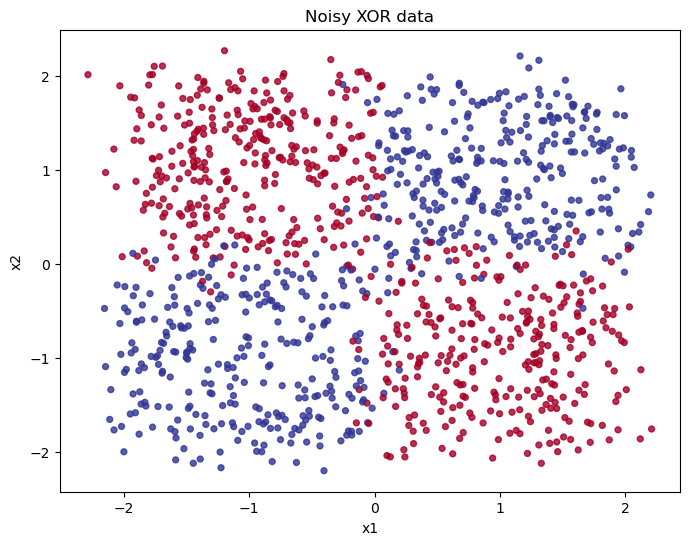

In [4]:
def plot_xor_data(X, y, title="Noisy XOR data"):
    X_cpu = X.detach().cpu()
    y_cpu = y.detach().cpu()
    plt.figure(figsize=(8, 6))
    plt.scatter(
        X_cpu[:, 0],
        X_cpu[:, 1],
        c=y_cpu,
        cmap=plt.cm.RdYlBu,
        s=18,
        alpha=0.8,
    )
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")


plot_xor_data(
    torch.cat([X_train, X_test]),
    torch.cat([y_train, y_test]),
)

## 3. Accuracy 함수

예측 라벨과 실제 라벨이 같은 비율을 백분율로 반환하세요.

In [5]:
def accuracy_fn(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    accuracy=(y_true == y_pred).sum().item()/ y_true.shape[0] # 여기에서 item() 함수로 숫자만을 가질 수 있게 만들어줌.
    return accuracy

## 4. 모델 정의

두 모델은 hidden layer의 크기는 다르지만 입력과 출력 형태는 같습니다.
첫 모델은 Linear 층만, 두 번째 모델은 Linear 층 사이에 ReLU를 넣으세요.

In [6]:
class XORLinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: 2 → 16 → 16 → 1인 Linear 층을 만드세요. 활성화 함수는 넣지 않습니다.
        hidden_units=16
        self.layers=nn.Sequential(
            nn.Linear(in_features=2, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: 마지막 차원을 없애 logits shape가 (batch_size,)가 되게 하세요
        return self.layers(x).squeeze(-1)


class XORNonlinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        hidden_units=16
        # TODO: 2 → 16 → 16 → 1 구조를 만들고 Linear 층 사이에 ReLU를 넣으세요
        self.layers =nn.Sequential(
            nn.Linear(in_features=2, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: 마지막 차원을 없애 logits shape가 (batch_size,)가 되게 하세요
        return self.layers(x).squeeze(-1)


torch.manual_seed(RANDOM_SEED)
linear_model = XORLinearModel().to(device)
torch.manual_seed(RANDOM_SEED)
nonlinear_model = XORNonlinearModel().to(device)

print(linear_model)
print(nonlinear_model)

XORLinearModel(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): Linear(in_features=16, out_features=16, bias=True)
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)
XORNonlinearModel(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 5. Logits → 확률 → 라벨

학습 전 비선형 모델의 출력 다섯 개를 이용해 변환 과정을 확인합니다.
확률은 sigmoid, 라벨은 threshold 0.5를 사용하세요.

In [ ]:
nonlinear_model.eval()
with torch.inference_mode():
    example_logits = nonlinear_model(X_test[:5].to(device))

# TODO: logits를 확률로 바꾸세요
example_probs = torch.sigmoid(example_logits)
# TODO: 확률이 0.5 이상이면 1, 아니면 0인 라벨을 만드세요
example_labels = torch.round(example_probs)

print("logits:", example_logits)
print("probabilities:", example_probs)
print("labels:", example_labels)

logits: tensor([0.1719, 0.2121, 0.1928, 0.2089, 0.2046], device='mps:0')
probabilities: tensor([0.5429, 0.5528, 0.5480, 0.5520, 0.5510], device='mps:0')
labels: tensor([1., 1., 1., 1., 1.], device='mps:0')


In [9]:
print("logits shape:", (nonlinear_model(X_test.to(device))).shape)
print("probabilities shape:", torch.sigmoid(nonlinear_model(X_test.to(device))).shape)
print("labels shape:", torch.round(torch.sigmoid(nonlinear_model(X_test.to(device)))).shape)

logits shape: torch.Size([240])
probabilities shape: torch.Size([240])
labels shape: torch.Size([240])


In [10]:
# 확인
assert example_logits.shape == example_probs.shape == example_labels.shape == (5,)
assert ((0 <= example_probs) & (example_probs <= 1)).all()

## 6. Loss function & Optimizer

- loss: `nn.BCEWithLogitsLoss`
- optimizer: `torch.optim.Adam`, `lr=0.01`

In [11]:
# TODO: loss_fn과 두 모델의 optimizer를 만드세요
loss_fn = torch.nn.BCEWithLogitsLoss()
linear_optimizer = torch.optim.Adam(params=linear_model.parameters(), lr=0.01)
nonlinear_optimizer = torch.optim.Adam(params=nonlinear_model.parameters(), lr=0.01)

## 7. 학습 함수 — 1,000 epochs

학습 5단계에 더해, 평가에서는 logits를 라벨로 변환해 accuracy를 계산합니다.
100 epoch마다, 그리고 마지막 epoch에 train/test 결과를 기록하세요.

In [12]:
def train_model(model, optimizer, epochs=1000):
    X_train_device = X_train.to(device) # device로 바꾸는 이유는 데이터와 모델읠 device가 다를 경우 계산이 안됨!
    y_train_device = y_train.to(device)
    X_test_device = X_test.to(device)
    y_test_device = y_test.to(device)

    history = {
        "epoch": [],
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": [],
    }

    for epoch in range(epochs):
        ### 학습 ###
        model.train()

        # TODO: forward → loss → zero_grad → backward → step
        train_logits = model(X_train_device).squeeze() # squeeze를 통해서 데이터의 차원이 1인 차원을 없애줌
        train_loss = loss_fn(train_logits, y_train_device) # loss를 계산

        optimizer.zero_grad() 
        train_loss.backward()
        optimizer.step()


        # TODO: train logits를 0/1 라벨로 바꾸고 accuracy를 계산하세요
        train_preds = torch.round(train_logits)
        train_acc = accuracy_fn(y_train_device, train_preds)

        ### 평가 ###
        model.eval()
        with torch.inference_mode():
            # TODO: test logits, loss, 예측 라벨, accuracy를 계산하세요
            test_logits = model(X_test_device).squeeze()
            test_loss = loss_fn(test_logits, y_test_device)
            test_preds = torch.round(test_logits)
            test_acc = accuracy_fn(y_test_device, test_preds)
        if epoch % 100 == 0 or epoch == epochs - 1:
            history["epoch"].append(epoch)
            history["train_loss"].append(train_loss.item())
            history["test_loss"].append(test_loss.item())
            history["train_acc"].append(train_acc)
            history["test_acc"].append(test_acc)
            print(
                f"Epoch: {epoch:4d} | "
                f"Train loss: {train_loss:.4f}, acc: {train_acc:5.1f}% | "
                f"Test loss: {test_loss:.4f}, acc: {test_acc:5.1f}%"
            )

    return history

## 8. 두 모델 학습

두 모델을 같은 epoch 수와 learning rate로 학습합니다.
선형 모델이 먼저 실행되므로 두 출력이 섞이지 않게 모델 이름을 확인하세요.

In [13]:
print("=== Linear model ===")
linear_history = train_model(linear_model, linear_optimizer, epochs=1000)

print("\n=== Nonlinear model ===")
nonlinear_history = train_model(nonlinear_model, nonlinear_optimizer, epochs=1000)

=== Linear model ===
Epoch:    0 | Train loss: 0.7352, acc:   0.4% | Test loss: 0.7056, acc:   0.5%
Epoch:  100 | Train loss: 0.6905, acc:   0.5% | Test loss: 0.6958, acc:   0.5%
Epoch:  200 | Train loss: 0.6905, acc:   0.5% | Test loss: 0.6958, acc:   0.5%
Epoch:  300 | Train loss: 0.6905, acc:   0.5% | Test loss: 0.6958, acc:   0.5%
Epoch:  400 | Train loss: 0.6905, acc:   0.5% | Test loss: 0.6958, acc:   0.5%
Epoch:  500 | Train loss: 0.6905, acc:   0.5% | Test loss: 0.6958, acc:   0.5%
Epoch:  600 | Train loss: 0.6905, acc:   0.5% | Test loss: 0.6958, acc:   0.5%
Epoch:  700 | Train loss: 0.6905, acc:   0.5% | Test loss: 0.6958, acc:   0.5%
Epoch:  800 | Train loss: 0.6905, acc:   0.5% | Test loss: 0.6958, acc:   0.5%
Epoch:  900 | Train loss: 0.6905, acc:   0.5% | Test loss: 0.6958, acc:   0.5%
Epoch:  999 | Train loss: 0.6905, acc:   0.5% | Test loss: 0.6958, acc:   0.5%

=== Nonlinear model ===
Epoch:    0 | Train loss: 0.6968, acc:   0.5% | Test loss: 0.6861, acc:   0.5%
Epoch:

## 9. 학습 곡선 저장

두 모델의 test loss와 test accuracy를 한 그림에 그려 `training_curves.png`로 저장하세요.

그래프 저장: training_curves.png


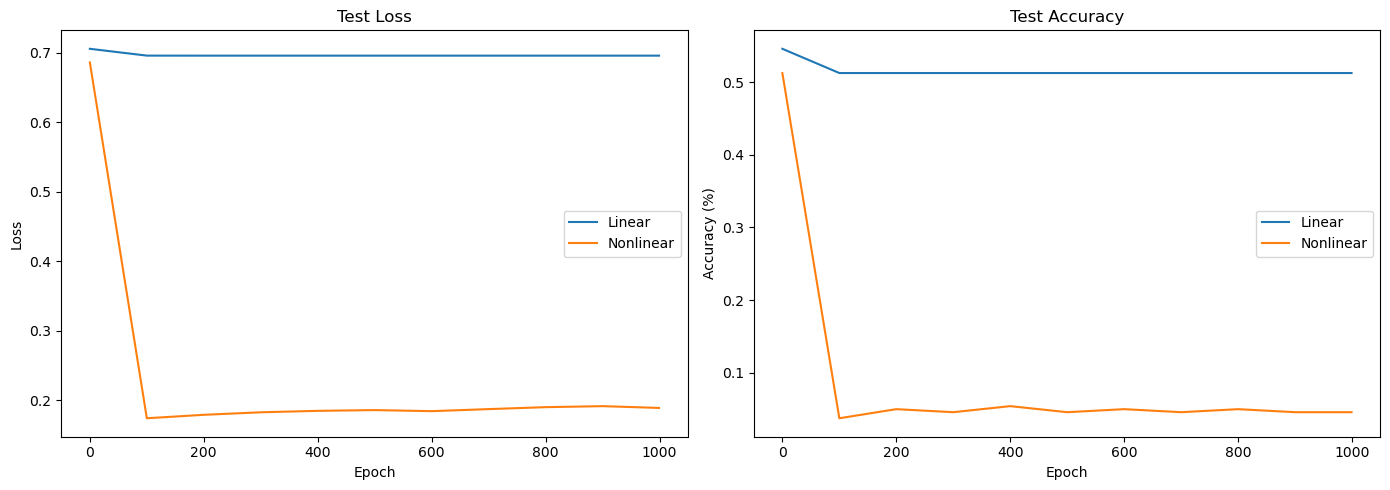

In [ ]:
# TODO: 왼쪽에는 test loss, 오른쪽에는 test accuracy를 그리세요.
#       각 축에 Linear/Nonlinear 범례, 제목, x/y 라벨을 넣으세요.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(linear_history['epoch'], linear_history['test_loss'], label='Linear')
axes[0].plot(nonlinear_history['epoch'], nonlinear_history['test_loss'], label='Nonlinear')
axes[0].set_title('Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(linear_history['epoch'], linear_history['test_acc'], label='Linear')
axes[1].plot(nonlinear_history['epoch'], nonlinear_history['test_acc'], label='Nonlinear')
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight") #그래프를 저장하기 위해서 plt.savefig()이용
print("그래프 저장: training_curves.png")

## 10. 결정경계 저장

주어진 시각화 함수를 사용해 두 모델을 전달해 결정경계를 각각 저장하세요.

그래프 저장: linear_decision_boundary.png
그래프 저장: nonlinear_decision_boundary.png


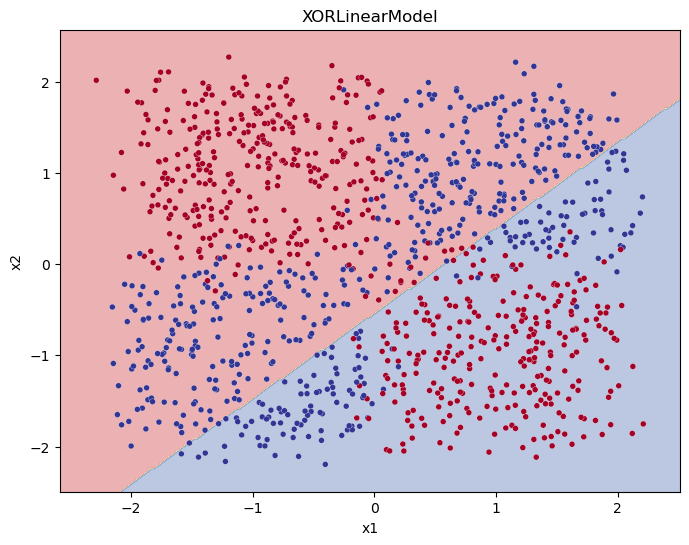

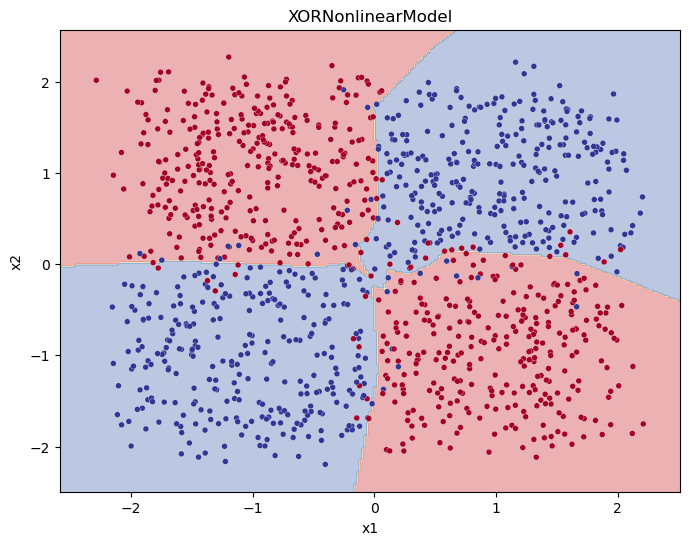

In [15]:
def plot_decision_boundary(model, X, y, save_path):
    model.eval()
    model_device = next(model.parameters()).device
    X_cpu = X.detach().cpu()
    y_cpu = y.detach().cpu()

    x1_min, x1_max = X_cpu[:, 0].min() - 0.3, X_cpu[:, 0].max() + 0.3
    x2_min, x2_max = X_cpu[:, 1].min() - 0.3, X_cpu[:, 1].max() + 0.3
    xx, yy = torch.meshgrid(
        torch.linspace(x1_min, x1_max, 250),
        torch.linspace(x2_min, x2_max, 250),
        indexing="xy",
    )
    grid = torch.column_stack((xx.reshape(-1), yy.reshape(-1))).to(model_device)

    with torch.inference_mode():
        grid_logits = model(grid)
        grid_preds = (torch.sigmoid(grid_logits) >= 0.5).float()

    plt.figure(figsize=(8, 6))
    plt.contourf(
        xx.numpy(),
        yy.numpy(),
        grid_preds.cpu().reshape(xx.shape).numpy(),
        alpha=0.35,
        cmap=plt.cm.RdYlBu,
    )
    plt.scatter(
        X_cpu[:, 0],
        X_cpu[:, 1],
        c=y_cpu,
        cmap=plt.cm.RdYlBu,
        s=18,
        edgecolors="white",
        linewidths=0.2,
    )
    plt.title(type(model).__name__)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"그래프 저장: {save_path}")


X_all = torch.cat([X_train, X_test])
y_all = torch.cat([y_train, y_test])

# TODO: 선형 모델과 비선형 모델의 결정경계를 각각 저장하세요
plot_decision_boundary(linear_model, X_all, y_all, save_path="linear_decision_boundary.png")
plot_decision_boundary(nonlinear_model, X_all, y_all, save_path="nonlinear_decision_boundary.png")

## 11. 결과 비교

마지막 test loss와 accuracy를 표로 만들고, 선형 모델과 비선형 모델의 차이를 확인하세요.

In [16]:
# TODO: model, test_loss, test_accuracy 열을 가진 DataFrame을 만드세요
comparison = pd.concat([
    pd.DataFrame(linear_history)[['test_loss', 'test_acc']].assign(model='linear'),
    pd.DataFrame(nonlinear_history)[['test_loss', 'test_acc']].assign(model='nonlinear')
], ignore_index=True)
comparison

,test_loss,test_acc,model
0,0.705623,0.545833,linear
1,0.695831,0.512500,linear
2,0.695790,0.512500,linear
3,0.695790,0.512500,linear
4,0.695790,0.512500,linear
5,0.695790,0.512500,linear
6,0.695790,0.512500,linear
7,0.695790,0.512500,linear
8,0.695790,0.512500,linear
9,0.695790,0.512500,linear


### 결과 해석

아래 질문에 답하세요.

1. Linear 층을 여러 개 연결했는데도 선형 모델이 XOR을 풀기 어려운 이유는 무엇인가요?
2. ReLU가 들어가면서 결정경계가 어떻게 달라졌나요?

> 답:

1번 답 XOR은 (부호가 같으면 1, 다르면 0으로) 1·3사분면과 2·4사분면이 서로 대각선으로 교차 배치되어 있어서, 하나의 직선으로는 절대 나눌 수 없는 선형적으로 분리 불가능한데이터다. 게다가 활성화 함수 없이 Linear 층을 아무리 여러 개 쌓아도, 선형 변환의 합성은 여전히 하나의 선형 변환일 뿐이라 표현력이 늘지 않는다. 그래서 layer 개수와 상관없이 XOR을 풀 수 없다.

2번 답 : ReLU 같은 비선형 활성화 함수가 각 층 사이에 들어가면서, 여러 층의 합성이 더 이상 하나의 선형 함수로 축약되지 않는다. 그 결과 모델이 곡선의 결정경계를 만들 수 있게 되어, 1·3사분면과 2·4사분면처럼 선형으로 분리 불가능한 데이터도 구분할 수 있게 되었다.

## 12. (선택 도전) Wine 다중분류

`sklearn.datasets.load_wine`은 13개 특성과 3개 클래스를 가진 데이터입니다.
특성을 표준화한 뒤 PyTorch 텐서로 바꾸고, `CrossEntropyLoss`를 사용해 test accuracy 90% 이상을 만들어 보세요.

- 모델의 마지막 출력은 3개여야 합니다.
- `CrossEntropyLoss`에는 softmax를 거치지 않은 logits를 전달합니다.
- 라벨은 `torch.long`이어야 합니다.
- 예측 라벨은 `argmax(dim=1)`로 만듭니다.

In [25]:
from sklearn.datasets import load_wine

# TODO: load_wine(return_X_y=True)로 입력과 라벨을 불러오세요
wine_X_np, wine_y_np = load_wine(return_X_y=True)

# TODO: train_test_split으로 80:20 분할하세요
#       random_state=RANDOM_SEED, stratify=wine_y_np를 사용하세요.
wine_X_train_np, wine_X_test_np, wine_y_train_np, wine_y_test_np = train_test_split(
    wine_X_np, wine_y_np,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=wine_y_np
)

# TODO: 입력은 torch.float32, 라벨은 torch.long 텐서로 바꾸세요
wine_X_train, wine_X_test = torch.tensor(wine_X_train_np, dtype=torch.float32), torch.tensor(wine_X_test_np, dtype=torch.float32)
wine_y_train, wine_y_test = torch.tensor(wine_y_train_np, dtype=torch.long), torch.tensor(wine_y_test_np, dtype=torch.long) # y는 정수형으로 바꿔준다.

# TODO: train 데이터의 평균과 표준편차만 사용해 train/test 입력을 표준화하세요
wine_mean= wine_X_train.mean(dim=0) # X의 features는 13개 이므로 열 별로 평균을 하기 위해서 dim=0 설정
wine_sd=wine_X_train.std(dim=0)

X_train= (wine_X_train-wine_mean)/wine_sd
X_test=  (wine_X_test-wine_mean)/wine_sd

# TODO: 13개 특성을 받아 3개 logits를 출력하는 모델을 만드세요
class wineModel(nn.Module):
    def __init__(self):
        super().__init__()
        hidden_units=16
        self.layers=nn.Sequential(
            nn.Linear(in_features=13, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=3),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layers(x)

wine_model = wineModel().to(device)

# TODO: CrossEntropyLoss와 optimizer를 만들고 모델을 학습하세요
loss_fn=torch.nn.CrossEntropyLoss()
wine_optimizer=torch.optim.Adam(wine_model.parameters(), lr=0.05)

In [26]:
print(wine_model(X_train.to(device)).shape)

torch.Size([142, 3])


In [27]:
def train_wine_model(model, optimizer, epochs=1000):
    X_train_device = X_train.to(device)
    y_train_device = wine_y_train.to(device)
    X_test_device = X_test.to(device)
    y_test_device = wine_y_test.to(device)

    history = {
        "epoch": [],
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": [],
    }

    for epoch in range(epochs):
        ### 학습 ###
        model.train()
        train_logits = model(X_train_device)
        train_loss = loss_fn(train_logits, y_train_device)
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        train_preds = train_logits.argmax(dim=1)
        train_acc = accuracy_fn(y_train_device, train_preds)

        ### 평가 ###
        model.eval()
        with torch.inference_mode():
            test_logits = model(X_test_device)
            test_loss = loss_fn(test_logits, y_test_device)
            test_preds = test_logits.argmax(dim=1)
            test_acc = accuracy_fn(y_test_device, test_preds)
        if epoch % 100 == 0 or epoch == epochs - 1:
            history["epoch"].append(epoch)
            history["train_loss"].append(train_loss.item())
            history["test_loss"].append(test_loss.item())
            history["train_acc"].append(train_acc)
            history["test_acc"].append(test_acc)
            print(
                f"Epoch: {epoch:4d} | "
                f"Train loss: {train_loss:.4f}, acc: {train_acc:5.1f}% | "
                f"Test loss: {test_loss:.4f}, acc: {test_acc:5.1f}%"
            )

    return history

In [28]:
result=train_wine_model(wine_model, wine_optimizer, epochs=1000)

Epoch:    0 | Train loss: 1.0473, acc:   0.4% | Test loss: 0.8181, acc:   0.8%
Epoch:  100 | Train loss: 0.0000, acc:   1.0% | Test loss: 0.1092, acc:   1.0%
Epoch:  200 | Train loss: 0.0000, acc:   1.0% | Test loss: 0.1024, acc:   1.0%
Epoch:  300 | Train loss: 0.0000, acc:   1.0% | Test loss: 0.0949, acc:   1.0%
Epoch:  400 | Train loss: 0.0000, acc:   1.0% | Test loss: 0.0881, acc:   1.0%
Epoch:  500 | Train loss: 0.0000, acc:   1.0% | Test loss: 0.0817, acc:   1.0%
Epoch:  600 | Train loss: 0.0000, acc:   1.0% | Test loss: 0.0759, acc:   1.0%
Epoch:  700 | Train loss: 0.0000, acc:   1.0% | Test loss: 0.0706, acc:   1.0%
Epoch:  800 | Train loss: 0.0000, acc:   1.0% | Test loss: 0.0657, acc:   1.0%
Epoch:  900 | Train loss: 0.0000, acc:   1.0% | Test loss: 0.0613, acc:   1.0%
Epoch:  999 | Train loss: 0.0000, acc:   1.0% | Test loss: 0.0573, acc:   1.0%


0.9722222222222222


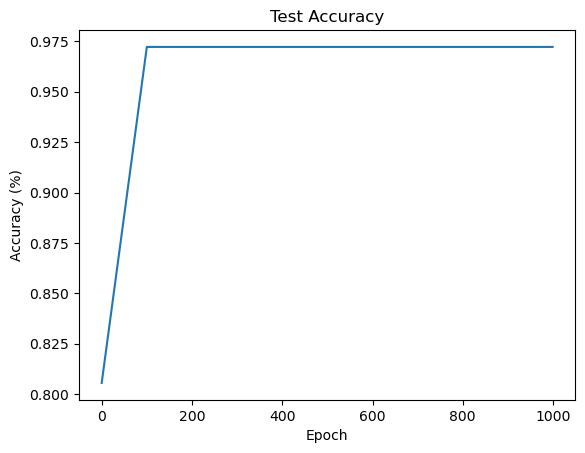

In [32]:
plt.plot(result['epoch'], result['test_acc'])
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
print(result['test_acc'][-1])

---

## 체크리스트

- [ ] 모든 셀이 위에서 아래로 에러 없이 실행됨
- [ ] logits, 확률, 라벨의 shape가 모두 `(240,)` 또는 예시 셀에서는 `(5,)`
- [ ] 비선형 모델의 test accuracy가 90% 이상
- [ ] `training_curves.png`가 생성됨
- [ ] `decision_boundary_linear.png`, `decision_boundary_nonlinear.png`가 생성됨
- [ ] `BCEWithLogitsLoss`에 sigmoid를 거치지 않은 logits를 전달함
- [ ] 두 모델의 결과 차이를 설명함